# A1 Coursework

## Question 1: Likelihood based analysis of the 21-cm power spectrum

### (a) PCA

In [13]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from apb86_a1 import (
    TrainingConfig,
    build_emulator,
    cumulative_explained_variance,
    fit_pca_with_observation,
    load_observations,
    load_simulation_dataset,
    normalize_observation,
    normalize_spectra,
    optimize_emulator,
    save_observations_pca,
    save_pca_model,
    save_split_datasets,
    split_training_data,
    test_emulator,
    train_emulator,
    )

# Load the data
data_path = "data"
observations = load_observations(data_path)
simulations = load_simulation_dataset(data_path)

observations_spectrum = observations.power
observations_ks = observations.k
ks = simulations.ks
spectra = simulations.spectra
params = simulations.params
redshift = simulations.redshift
code = simulations.code
code_version = simulations.code_version

[0.00166234 0.00187171 0.00210745 0.00237288 0.00267174 0.00300824
 0.00338713 0.00381373 0.00429407 0.0048349  0.00544385 0.00612949
 0.0069015  0.00777073 0.00874945 0.00985143 0.0110922  0.01248925
 0.01406226 0.01583338 0.01782758 0.02007294 0.0226011  0.02544768
 0.02865278 0.03226156 0.03632487 0.04089994 0.04605123 0.05185133
 0.05838194 0.06573507 0.07401432 0.08333633 0.09383244 0.10565052
 0.11895707 0.13393956 0.15080909 0.1698033  0.19118982 0.21526993
 0.24238291 0.27291074 0.30728351 0.34598548 0.38956192 0.43862676
 0.49387125 0.55607372 0.62611051 0.70496834 0.79375823 0.89373108]
('k', 'power', 'astro_params', 'cosmo_params', 'redshfit', 'code', 'code_version')
651.2313486608382
9997 54


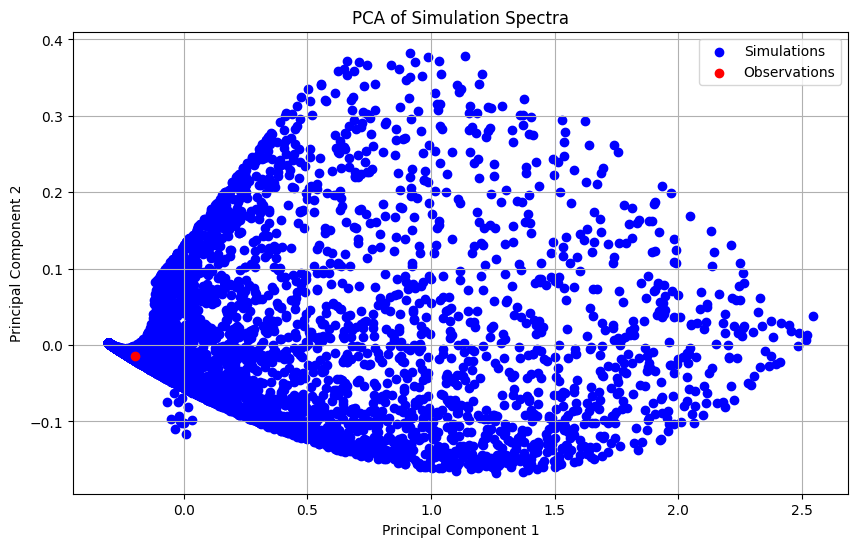

In [14]:
print(observations_ks)
print(("k", "power", "astro_params", "cosmo_params", "redshfit", "code", "code_version"))

normalized_spectra, normalization_stats = normalize_spectra(spectra)
max_power = normalization_stats.max_power
min_power = normalization_stats.min_power
print(max_power)

num_samples, num_features = normalized_spectra.shape
print(num_samples, num_features)
reshaped_spectra = normalized_spectra
normalized_observations_spectrum = normalize_observation(
    observations_spectrum, normalization_stats
 )

pca_results = fit_pca_with_observation(
    reshaped_spectra,
    normalized_observations_spectrum,
    n_components=2,
 )
pca_2 = pca_results.pca_model
pca_2_simulations_spectra_result = pca_results.simulation_components
pca_2_observations_result = pca_results.observation_components

plt.figure(figsize=(10, 6))
plt.scatter(pca_2_simulations_spectra_result[:, 0], pca_2_simulations_spectra_result[:, 1], c='blue', label='Simulations')
plt.scatter(pca_2_observations_result[:, 0], pca_2_observations_result[:, 1], c='red', label='Observations')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Simulation Spectra')
plt.legend()
plt.grid()
plt.show()

In [15]:
from sklearn.decomposition import PCA

pca_54 = PCA(n_components=54)
pca_54_result = pca_54.fit_transform(reshaped_spectra)
print(pca_54_result.shape)
print(pca_54.explained_variance_ratio_)
print(cumulative_explained_variance(pca_54))

(9997, 54)
[9.83683248e-01 1.59701021e-02 3.08602656e-04 3.79835558e-05
 5.35958706e-08 9.23860033e-09 1.55247047e-10 9.77364245e-11
 2.62700375e-11 2.41917717e-11 1.65674435e-11 1.43045844e-11
 1.12155999e-11 8.92834470e-12 7.90849637e-12 6.94061515e-12
 5.67009430e-12 4.69327641e-12 4.21970674e-12 2.28938970e-12
 1.98738868e-12 1.43492451e-12 1.25743908e-12 1.00578391e-12
 9.37985357e-13 6.72042883e-13 5.22987274e-13 4.28659028e-13
 4.20514398e-13 3.53658335e-13 2.12768137e-13 1.99894699e-13
 1.13771480e-13 4.45874869e-14 4.05045560e-14 1.51843870e-14
 8.27777687e-15 5.18232489e-16 1.65823109e-16 9.08305204e-17
 7.38574625e-17 5.23910871e-17 3.40344609e-17 3.03690518e-17
 2.09527238e-17 1.43533108e-17 2.61825483e-18 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]
[0.98368325 0.99965335 0.99996195 0.99999994 0.99999999 1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1

[0.00166234 0.00187171 0.00210745 0.00237288 0.00267174 0.00300824
 0.00338713 0.00381373 0.00429407 0.0048349  0.00544385 0.00612949
 0.0069015  0.00777073 0.00874945 0.00985143 0.0110922  0.01248925
 0.01406226 0.01583338 0.01782758 0.02007294 0.0226011  0.02544768
 0.02865278 0.03226156 0.03632487 0.04089994 0.04605123 0.05185133
 0.05838194 0.06573507 0.07401432 0.08333633 0.09383244 0.10565052
 0.11895707 0.13393956 0.15080909 0.1698033  0.19118982 0.21526993
 0.24238291 0.27291074 0.30728351 0.34598548 0.38956192 0.43862676
 0.49387125 0.55607372 0.62611051 0.70496834 0.79375823 0.89373108]


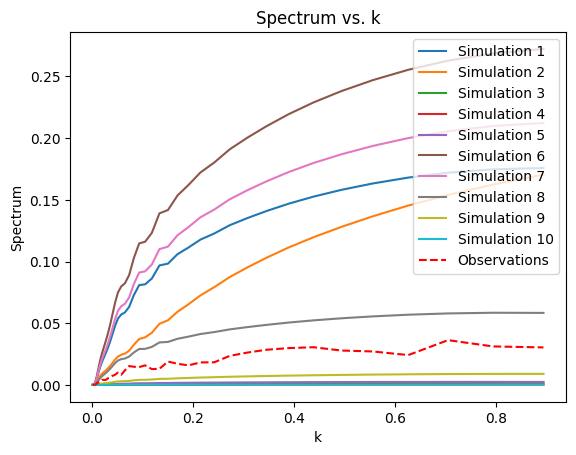

In [16]:
print(ks[0])

for i in range(10):
    plt.plot(ks[i], reshaped_spectra[i], label=f"Simulation {i+1}")

plt.plot(observations_ks, normalized_observations_spectrum, label="Observations", linestyle='dashed', color='red')

#plt.plot(labels, observations, label="Observations", linestyle='dashed')
plt.xlabel("k")
plt.ylabel("Spectrum")
plt.title("Spectrum vs. k")
plt.legend()
plt.show()

We use 2 principal components, which together explain $>99.96\%$ of the variance in the data. We now split the normalised and decomposed simulations into training, validation, and testing samples using an 80:10:10 split. We also apply the same normalisation and PCA reduction to the observed power spectrum.

In [17]:
# Split the data into training, validation, and test sets with 80-10-10 split
splits = split_training_data(
    params,
    pca_2_simulations_spectra_result,
    train_fraction=0.8,
    val_fraction=0.1,
    test_fraction=0.1,
    random_state=42,
 )
X_train = splits.x_train
X_val = splits.x_val
X_test = splits.x_test
y_train = splits.y_train
y_val = splits.y_val
y_test = splits.y_test
print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

save_split_datasets(
    data_path,
    x_train=X_train,
    y_train=y_train,
    x_val=X_val,
    y_val=y_val,
    x_test=X_test,
    y_test=y_test,
 )
save_observations_pca(Path(data_path) / "observations_pca.npz", pca_2_observations_result)
save_pca_model(Path(data_path) / "pca_model.pkl", pca_2)

Training set size: 7997
Validation set size: 1000
Test set size: 1000


### (b)

The data is normalised by subtracting the minimum power in the simulations and dividing by the difference between the maximum power and the minimum power in the simulations.

In [18]:
training_config = TrainingConfig(epochs=200, validation_interval=10)
model = build_emulator(hidden_units=training_config.hidden_units, device=training_config.device)
history = train_emulator(
    model,
    X_train,
    y_train,
    x_val=X_val,
    y_val=y_val,
    config=training_config,
 )

for epoch_number, val_loss in zip(
    range(
        training_config.validation_interval,
        training_config.epochs + 1,
        training_config.validation_interval,
    ),
    history.val_loss,
 ):
    train_loss = history.train_loss[epoch_number - 1]
    print(
        f"Epoch [{epoch_number}/{training_config.epochs}], "
        f"Loss: {train_loss:.4f}, Validation Loss: {val_loss:.4f}"
    )

evaluation = test_emulator(model, X_test, y_test)
print(f"Test MSE: {evaluation.mse:.4f}")

Epoch [10/200], Loss: 0.1092, Validation Loss: 0.1004
Epoch [20/200], Loss: 0.0657, Validation Loss: 0.0589
Epoch [30/200], Loss: 0.0278, Validation Loss: 0.0238
Epoch [40/200], Loss: 0.0144, Validation Loss: 0.0116
Epoch [50/200], Loss: 0.0091, Validation Loss: 0.0082
Epoch [60/200], Loss: 0.0072, Validation Loss: 0.0069
Epoch [70/200], Loss: 0.0060, Validation Loss: 0.0057
Epoch [80/200], Loss: 0.0050, Validation Loss: 0.0047
Epoch [90/200], Loss: 0.0043, Validation Loss: 0.0040
Epoch [100/200], Loss: 0.0037, Validation Loss: 0.0035
Epoch [110/200], Loss: 0.0031, Validation Loss: 0.0029
Epoch [120/200], Loss: 0.0027, Validation Loss: 0.0025
Epoch [130/200], Loss: 0.0027, Validation Loss: 0.0023
Epoch [140/200], Loss: 0.0022, Validation Loss: 0.0020
Epoch [150/200], Loss: 0.0019, Validation Loss: 0.0018
Epoch [160/200], Loss: 0.0017, Validation Loss: 0.0016
Epoch [170/200], Loss: 0.0015, Validation Loss: 0.0015
Epoch [180/200], Loss: 0.0013, Validation Loss: 0.0014
Epoch [190/200], Lo

In [ ]:
# Optimize the model hyperparameters using Optuna
best_model_path = Path(data_path) / "best_optimized_model.pt"
optimization_curves_path = Path(data_path) / "optimization_curves.png"

optimization_result = optimize_emulator(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=200,
    n_trials=20,
    early_stopping_patience=20,
    early_stopping_min_delta=1e-5,
    min_epochs_before_stopping=30,
    best_model_path=best_model_path,
    training_curves_plot_path=optimization_curves_path,
    representative_trial_count=3,
 )
study = optimization_result.study
print("Best hyperparameters: ", optimization_result.best_params)
print("Best validation loss: ", optimization_result.best_value)
print("Best optimized model saved to:", optimization_result.best_model_path)
print("Optimization curves saved to:", optimization_result.training_curves_plot_path)

from IPython.display import Image, display
if optimization_result.training_curves_plot_path is not None:
    display(Image(filename=optimization_result.training_curves_plot_path))

[I 2026-03-17 11:52:48,206] A new study created in memory with name: no-name-f260c20e-5e2c-4f92-9001-aba22232faf4
[I 2026-03-17 11:52:49,378] Trial 0 finished with value: 0.0020749911200255156 and parameters: {'n_hidden_units_1': 128, 'n_hidden_units_2': 64, 'n_hidden_units_3': 32}. Best is trial 0 with value: 0.0020749911200255156.
[I 2026-03-17 11:52:52,735] Trial 1 finished with value: 0.0005475239013321698 and parameters: {'n_hidden_units_1': 256, 'n_hidden_units_2': 128, 'n_hidden_units_3': 32}. Best is trial 1 with value: 0.0005475239013321698.
[I 2026-03-17 11:52:55,295] Trial 2 finished with value: 0.001124597038142383 and parameters: {'n_hidden_units_1': 64, 'n_hidden_units_2': 256, 'n_hidden_units_3': 16}. Best is trial 1 with value: 0.0005475239013321698.
[I 2026-03-17 11:52:55,638] Trial 3 finished with value: 0.004322281572967768 and parameters: {'n_hidden_units_1': 16, 'n_hidden_units_2': 32, 'n_hidden_units_3': 16}. Best is trial 1 with value: 0.0005475239013321698.
[I 2

Best hyperparameters:  {'n_hidden_units_1': 128, 'n_hidden_units_2': 256, 'n_hidden_units_3': 256}
Best validation loss:  0.0002538450644351542
